In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

Load Dataset

In [2]:
file_path = "../datasets/phase_2/paysim-dataset-phase2.parquet"
df = pd.read_parquet(file_path)
df.head()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,cluster_kmeans,cluster_hdbscan
0,1,-0.332937,1.452975,-0.140722,0,-0.969372,0.00000,1,0,False,False,False,True,False,2,0
1,1,-0.373767,0.065605,-0.140722,0,-0.183663,0.00000,1,0,False,False,False,True,False,2,0
2,1,-0.382384,-0.130713,-0.140722,1,-0.017832,0.00000,0,1,False,False,False,False,True,2,0
3,1,-0.382384,-0.130713,-0.118260,1,-0.017832,-0.14206,0,1,False,True,False,False,False,2,0
4,1,-0.323576,0.254812,-0.140722,0,-1.149510,0.00000,1,0,False,False,False,True,False,2,0


In [3]:
def discretize_numeric_series(series, col_name, q=5):
    labels_map = {
        1: ["all"],
        2: ["low", "high"],
        3: ["low", "medium", "high"],
        4: ["very_low", "low", "high", "very_high"],
        5: ["very_low", "low", "medium", "high", "very_high"],
    }

    s = pd.to_numeric(series, errors="coerce")

    if s.nunique(dropna=True) <= 1:
        return None

    try:
        codes, bins = pd.qcut(
            s,
            q=q,
            labels=False,
            retbins=True,
            duplicates="drop"
        )

        n_bins = len(bins) - 1

        if n_bins <= 0:
            return None

        labels = labels_map.get(n_bins, [f"bin_{i}" for i in range(n_bins)])
        mapped = codes.map(lambda x: f"{col_name}_{labels[int(x)]}" if pd.notna(x) else np.nan)

        categories = [f"{col_name}_{label}" for label in labels]
        return pd.Categorical(mapped, categories=categories)

    except Exception as e:
        print(f"Failed to discretize {col_name}: {e}")
        return None

In [4]:
def build_basket(df):
    basket_parts = []

    type_cols = [col for col in df.columns if col.startswith("type_")]
    if type_cols:
        basket_parts.append(df[type_cols].astype(bool))

    if "isFraud" in df.columns:
        fraud_items = pd.DataFrame(index=df.index)
        fraud_items["isFraud_yes"] = df["isFraud"].astype(int) == 1
        fraud_items["isFraud_no"] = df["isFraud"].astype(int) == 0
        basket_parts.append(fraud_items)

    if "isDestMerchant" in df.columns:
        merchant_items = pd.DataFrame(index=df.index)
        merchant_items["dest_merchant_yes"] = df["isDestMerchant"].astype(int) == 1
        merchant_items["dest_merchant_no"] = df["isDestMerchant"].astype(int) == 0
        basket_parts.append(merchant_items)

    if "origDrainedToZero" in df.columns:
        drained_items = pd.DataFrame(index=df.index)
        drained_items["orig_drained_yes"] = df["origDrainedToZero"].astype(int) == 1
        drained_items["orig_drained_no"] = df["origDrainedToZero"].astype(int) == 0
        basket_parts.append(drained_items)

    if "cluster_kmeans" in df.columns:
        cluster_items = pd.get_dummies(
            df["cluster_kmeans"].astype(str),
            prefix="cluster_kmeans"
        ).astype(bool)
        basket_parts.append(cluster_items)

    if "cluster_hdbscan" in df.columns:
        hdbscan_items = pd.DataFrame(index=df.index)
        hdbscan_items["hdbscan_outlier"] = df["cluster_hdbscan"] == -1
        hdbscan_items["hdbscan_normal"] = df["cluster_hdbscan"] != -1
        basket_parts.append(hdbscan_items)

    numeric_cols = [
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "balanceDiffOrig",
        "balanceDiffDest"
    ]

    for col in numeric_cols:
        if col in df.columns:
            cat = discretize_numeric_series(df[col], col_name=col, q=5)

            if cat is not None:
                dummies = pd.get_dummies(cat).astype(bool)
                basket_parts.append(dummies)
                print(f"Discretized {col}: {list(dummies.columns)}")
            else:
                print(f"Skipped {col}: not enough unique values")

    basket = pd.concat(basket_parts, axis=1)
    basket = basket.fillna(False).astype(bool)

    basket = basket.loc[:, basket.any(axis=0)]

    return basket


basket = build_basket(df)

print("Basket shape:", basket.shape)
display(basket.head())

Discretized amount: ['amount_very_low', 'amount_low', 'amount_medium', 'amount_high', 'amount_very_high']
Discretized oldbalanceOrg: ['oldbalanceOrg_very_low', 'oldbalanceOrg_low', 'oldbalanceOrg_high', 'oldbalanceOrg_very_high']
Discretized oldbalanceDest: ['oldbalanceDest_low', 'oldbalanceDest_medium', 'oldbalanceDest_high']
Discretized balanceDiffOrig: ['balanceDiffOrig_very_low', 'balanceDiffOrig_low', 'balanceDiffOrig_medium', 'balanceDiffOrig_high', 'balanceDiffOrig_very_high']
Discretized balanceDiffDest: ['balanceDiffDest_very_low', 'balanceDiffDest_low', 'balanceDiffDest_high', 'balanceDiffDest_very_high']
Basket shape: (6362604, 38)


,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud_yes,isFraud_no,dest_merchant_yes,dest_merchant_no,orig_drained_yes,...,oldbalanceDest_high,balanceDiffOrig_very_low,balanceDiffOrig_low,balanceDiffOrig_medium,balanceDiffOrig_high,balanceDiffOrig_very_high,balanceDiffDest_very_low,balanceDiffDest_low,balanceDiffDest_high,balanceDiffDest_very_high
0,False,False,False,True,False,False,True,True,False,False,...,False,False,True,False,False,False,True,False,False,False
1,False,False,False,True,False,False,True,True,False,False,...,False,False,True,False,False,False,True,False,False,False
2,False,False,False,False,True,True,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
3,False,True,False,False,False,True,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
4,False,False,False,True,False,False,True,True,False,False,...,False,False,True,False,False,False,True,False,False,False


,support
isFraud_no,0.998712
hdbscan_normal,0.991466
orig_drained_no,0.761013
dest_merchant_no,0.661853
oldbalanceDest_low,0.600000
balanceDiffDest_very_low,0.558913
cluster_kmeans_0,0.400987
oldbalanceOrg_very_low,0.400000
balanceDiffOrig_medium,0.380076
cluster_kmeans_1,0.378673


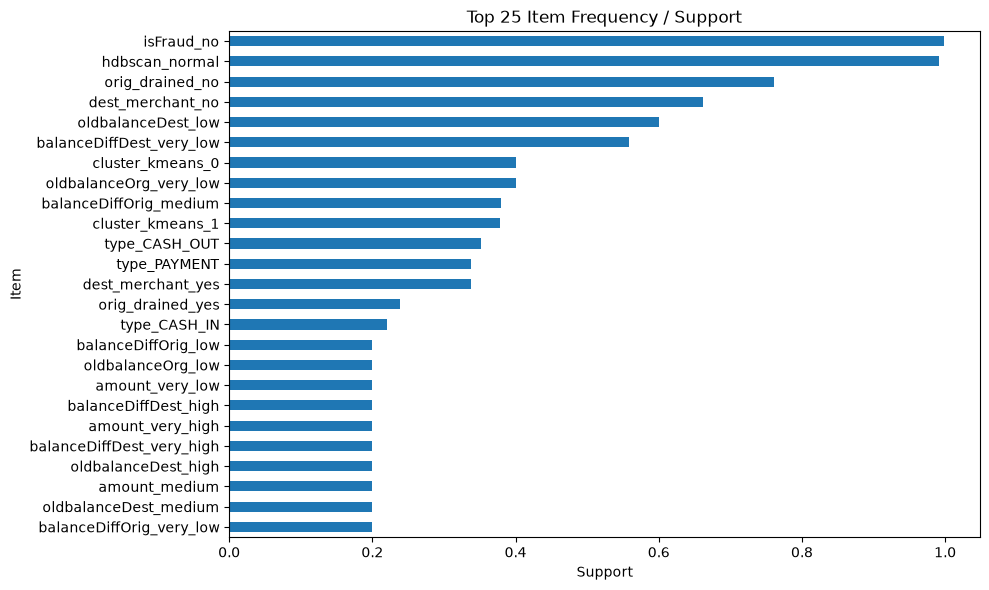

In [5]:
item_frequency = basket.mean().sort_values(ascending=False).to_frame("support")
display(item_frequency)

plt.figure(figsize=(10, 6))
item_frequency.head(25)["support"].sort_values().plot(kind="barh")
plt.title("Top 25 Item Frequency / Support")
plt.xlabel("Support")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

In [6]:
MIN_SUPPORT = 0.005
MIN_CONFIDENCE = 0.50
MIN_LIFT = 1.20
MAX_LEN = 3

In [7]:
frequent_itemsets = apriori(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_LEN,
    low_memory=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

print("Frequent itemsets found:", len(frequent_itemsets))
display(frequent_itemsets.head(20))

Frequent itemsets found: 3494


,support,itemsets
0,0.998712,frozenset({isFraud_no})
1,0.991466,frozenset({hdbscan_normal})
2,0.990414,"frozenset({hdbscan_normal, isFraud_no})"
3,0.761013,frozenset({orig_drained_no})
4,0.760984,"frozenset({orig_drained_no, isFraud_no})"
5,0.754360,"frozenset({orig_drained_no, hdbscan_normal})"
6,0.754335,"frozenset({orig_drained_no, hdbscan_normal, is..."
7,0.661853,frozenset({dest_merchant_no})
8,0.660565,"frozenset({dest_merchant_no, isFraud_no})"
9,0.657355,"frozenset({dest_merchant_no, hdbscan_normal})"


In [8]:
if len(frequent_itemsets) == 0:
    raise ValueError("No frequent itemsets found. Coba turunkan MIN_SUPPORT.")

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=MIN_LIFT
)

rules = rules[
    (rules["confidence"] >= MIN_CONFIDENCE) &
    (rules["lift"] >= MIN_LIFT)
].copy()

rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)

rules = rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Rules generated after filtering:", len(rules))
display(rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Rules generated after filtering: 2189


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"amount_very_low, type_CASH_IN",balanceDiffOrig_high,0.007382,1.000000,50.205189,0.007235,inf
1,type_DEBIT,"amount_very_low, balanceDiffDest_low",0.005448,0.836672,49.967743,0.005339,6.020135
2,type_DEBIT,"amount_very_low, dest_merchant_no",0.005905,0.906763,35.560732,0.005739,10.451858
3,balanceDiffOrig_high,"amount_low, type_CASH_IN",0.012537,0.629399,30.722739,0.012128,2.643041
4,"amount_low, type_CASH_IN",balanceDiffOrig_high,0.012537,0.611944,30.722739,0.012128,2.525616
5,type_DEBIT,"balanceDiffDest_low, orig_drained_no",0.005123,0.786687,22.988805,0.004900,4.527515
6,"amount_very_low, type_CASH_OUT",balanceDiffDest_low,0.010410,0.923780,22.483356,0.009947,12.580795
7,"amount_very_low, type_DEBIT",balanceDiffDest_low,0.005448,0.922702,22.457134,0.005206,12.405438
8,"orig_drained_no, type_DEBIT",balanceDiffDest_low,0.005123,0.910345,22.156384,0.004892,10.695611
9,type_DEBIT,"balanceDiffDest_low, isFraud_no",0.005872,0.901767,21.972644,0.005605,9.762067


In [9]:
def filter_meaningful_rules(rules):
    if len(rules) == 0:
        return rules.copy()

    filtered = rules.copy()

    trivial_consequents = [
        "isFraud_no",
        "hdbscan_normal",
        "orig_drained_no",
        "dest_merchant_no"
    ]

    for keyword in trivial_consequents:
        filtered = filtered[
            ~filtered["consequents_str"].str.contains(keyword, regex=False, na=False)
        ]

    important_mask = (
        filtered["consequents_str"].str.contains("isFraud_yes", regex=False, na=False) |
        filtered["consequents_str"].str.contains("hdbscan_outlier", regex=False, na=False) |
        filtered["consequents_str"].str.contains("cluster_kmeans", regex=False, na=False) |
        filtered["consequents_str"].str.contains("very_high", regex=False, na=False) |
        filtered["consequents_str"].str.contains("very_low", regex=False, na=False) |
        filtered["consequents_str"].str.contains("orig_drained_yes", regex=False, na=False) |
        filtered["consequents_str"].str.contains("dest_merchant_yes", regex=False, na=False)
    )

    filtered = filtered[important_mask].copy()

    return filtered.sort_values(
        by=["lift", "confidence", "support"],
        ascending=[False, False, False]
    ).reset_index(drop=True)


meaningful_rules = filter_meaningful_rules(rules)

print("Meaningful rules:", len(meaningful_rules))
display(meaningful_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Meaningful rules: 762


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,type_DEBIT,"amount_very_low, balanceDiffDest_low",0.005448,0.836672,49.967743,0.005339,6.020135e+00
1,"oldbalanceOrg_high, orig_drained_yes",balanceDiffOrig_very_low,0.064712,1.000000,4.999999,0.051770,inf
2,"oldbalanceOrg_very_high, orig_drained_yes",balanceDiffOrig_very_low,0.007182,1.000000,4.999999,0.005746,inf
3,"amount_medium, type_CASH_IN",balanceDiffOrig_very_high,0.067226,0.999974,4.999871,0.053781,3.110873e+04
4,"amount_high, type_CASH_IN",balanceDiffOrig_very_high,0.072741,0.999974,4.999870,0.058192,3.085547e+04
5,"amount_very_high, type_CASH_IN",balanceDiffOrig_very_high,0.052083,0.999973,4.999863,0.041666,2.945724e+04
6,"oldbalanceOrg_very_high, type_TRANSFER",balanceDiffOrig_very_low,0.005221,0.986928,4.934642,0.004163,6.120182e+01
7,"balanceDiffDest_high, oldbalanceOrg_high",balanceDiffOrig_very_low,0.037601,0.986715,4.933576,0.029980,6.022005e+01
8,"amount_very_high, balanceDiffOrig_medium",balanceDiffDest_very_high,0.075478,0.985906,4.929532,0.060167,5.676364e+01
9,"amount_very_high, type_TRANSFER",balanceDiffDest_very_high,0.059191,0.985846,4.929230,0.047183,5.652169e+01


In [10]:
report_rules = meaningful_rules.copy()

report_rules = report_rules[
    ~report_rules["consequents_str"].str.contains(
        "balanceDiffOrig|balanceDiffDest",
        regex=True,
        na=False
    )
].copy()

report_rules = report_rules[
    ~report_rules["antecedents_str"].str.contains(
        "balanceDiffOrig|balanceDiffDest",
        regex=True,
        na=False
    )
].copy()

report_rules = report_rules[
    ~report_rules["consequents_str"].str.contains(
        "isFraud_no|hdbscan_normal|orig_drained_no|dest_merchant_no",
        regex=True,
        na=False
    )
].copy()

report_rules = report_rules[
    (report_rules["confidence"] >= 0.30) &
    (report_rules["lift"] >= 1.20)
].copy()

report_rules = report_rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Report-worthy rules:", len(report_rules))

display(report_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(30))

Report-worthy rules: 192


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"oldbalanceOrg_very_high, orig_drained_yes",amount_very_high,0.006731,0.937150,4.685749,0.005294,12.728690
1,"orig_drained_no, type_DEBIT",amount_very_low,0.005224,0.928416,4.642075,0.004099,11.175651
2,"dest_merchant_no, type_DEBIT",amount_very_low,0.005905,0.906763,4.533810,0.004602,8.580272
3,type_DEBIT,amount_very_low,0.005905,0.906763,4.533810,0.004602,8.580272
4,"isFraud_no, type_DEBIT",amount_very_low,0.005905,0.906763,4.533810,0.004602,8.580272
5,"hdbscan_normal, type_DEBIT",amount_very_low,0.005806,0.906347,4.531733,0.004525,8.542204
6,"oldbalanceOrg_low, type_TRANSFER",orig_drained_yes,0.014506,0.984049,4.117581,0.010983,47.710313
7,"oldbalanceDest_high, type_TRANSFER",amount_very_high,0.029722,0.817248,4.086239,0.022449,4.377516
8,"oldbalanceOrg_low, type_CASH_OUT",orig_drained_yes,0.070136,0.951872,3.982940,0.052527,15.812155
9,"orig_drained_yes, type_TRANSFER",amount_very_high,0.028106,0.782058,3.910291,0.020918,3.670705


In [11]:
important_items = [
    "isFraud_yes",
    "isFraud_no",
    "hdbscan_outlier",
    "hdbscan_normal",
    "orig_drained_yes",
    "orig_drained_no",
    "dest_merchant_yes",
    "dest_merchant_no"
]

for item in important_items:
    if item in basket.columns:
        print(f"{item}: {basket[item].mean():.6f} ({basket[item].mean() * 100:.4f}%)")

isFraud_yes: 0.001288 (0.1288%)
isFraud_no: 0.998712 (99.8712%)
hdbscan_outlier: 0.008534 (0.8534%)
hdbscan_normal: 0.991466 (99.1466%)
orig_drained_yes: 0.238987 (23.8987%)
orig_drained_no: 0.761013 (76.1013%)
dest_merchant_yes: 0.338147 (33.8147%)
dest_merchant_no: 0.661853 (66.1853%)


In [12]:
fraud_itemsets = apriori(
    basket,
    min_support=0.0001,
    use_colnames=True,
    max_len=3,
    low_memory=True
)

fraud_rules = association_rules(
    fraud_itemsets,
    metric="lift",
    min_threshold=1.2
)

fraud_rules["antecedents_str"] = fraud_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

fraud_rules["consequents_str"] = fraud_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

fraud_rules = fraud_rules[
    fraud_rules["consequents_str"].str.contains("isFraud_yes", regex=False, na=False)
].copy()

fraud_rules = fraud_rules[
    ~fraud_rules["antecedents_str"].str.contains(
        "balanceDiffOrig|balanceDiffDest|isFraud_no",
        regex=True,
        na=False
    )
].copy()

fraud_rules = fraud_rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Fraud rules:", len(fraud_rules))

display(fraud_rules[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]].head(20))

Fraud rules: 234


,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"hdbscan_outlier, type_TRANSFER",isFraud_yes,0.000119,0.146664,113.842310,0.000117,1.170362
1,"hdbscan_outlier, orig_drained_yes",isFraud_yes,0.000231,0.122942,95.428902,0.000229,1.138706
2,"oldbalanceOrg_very_high, orig_drained_yes",isFraud_yes,0.000834,0.116115,90.129927,0.000825,1.129912
3,"amount_very_high, hdbscan_outlier",isFraud_yes,0.000153,0.113382,88.008077,0.000151,1.126428
4,"hdbscan_outlier, oldbalanceOrg_very_high",isFraud_yes,0.000160,0.090942,70.589854,0.000158,1.098622
5,"oldbalanceOrg_very_high, type_TRANSFER",isFraud_yes,0.000431,0.081430,63.206535,0.000424,1.087246
6,hdbscan_outlier,"cluster_kmeans_2, isFraud_yes",0.000107,0.012561,60.543776,0.000105,1.012510
7,"hdbscan_outlier, type_CASH_OUT",isFraud_yes,0.000118,0.058415,45.342557,0.000115,1.060671
8,"dest_merchant_no, hdbscan_outlier",isFraud_yes,0.000236,0.052521,40.767571,0.000230,1.054073
9,"cluster_kmeans_3, type_TRANSFER",isFraud_yes,0.000238,0.046773,36.306001,0.000232,1.047717


In [13]:
selected_parts = []

if "fraud_rules" in globals() and len(fraud_rules) > 0:
    selected_parts.append(fraud_rules.head(4))

outlier_rules = report_rules[
    report_rules["consequents_str"].str.contains("hdbscan_outlier", regex=False, na=False)
].copy()

if len(outlier_rules) > 0:
    selected_parts.append(outlier_rules.head(2))

cluster_rules = report_rules[
    report_rules["consequents_str"].str.contains("cluster_kmeans", regex=False, na=False)
].copy()

if len(cluster_rules) > 0:
    selected_parts.append(cluster_rules.head(2))

general_rules = report_rules[
    ~report_rules["consequents_str"].str.contains(
        "isFraud_yes|hdbscan_outlier|cluster_kmeans",
        regex=True,
        na=False
    )
].copy()

if len(general_rules) > 0:
    selected_parts.append(general_rules.head(5))

top_10_final = pd.concat(selected_parts, ignore_index=True)

top_10_final = top_10_final.drop_duplicates(
    subset=["antecedents_str", "consequents_str"]
)

if len(top_10_final) < 10:
    filler = report_rules[
        ~report_rules.set_index(["antecedents_str", "consequents_str"]).index.isin(
            top_10_final.set_index(["antecedents_str", "consequents_str"]).index
        )
    ].copy()

    top_10_final = pd.concat(
        [top_10_final, filler.head(10 - len(top_10_final))],
        ignore_index=True
    )

top_10_final = top_10_final.head(10).copy()

display(top_10_final[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]])

,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"hdbscan_outlier, type_TRANSFER",isFraud_yes,0.000119,0.146664,113.842310,0.000117,1.170362
1,"hdbscan_outlier, orig_drained_yes",isFraud_yes,0.000231,0.122942,95.428902,0.000229,1.138706
2,"oldbalanceOrg_very_high, orig_drained_yes",isFraud_yes,0.000834,0.116115,90.129927,0.000825,1.129912
3,"amount_very_high, hdbscan_outlier",isFraud_yes,0.000153,0.113382,88.008077,0.000151,1.126428
4,"amount_medium, type_PAYMENT",cluster_kmeans_1,0.010306,0.547158,1.444935,0.003173,1.372061
5,"amount_medium, dest_merchant_yes",cluster_kmeans_1,0.010306,0.547158,1.444935,0.003173,1.372061
6,"oldbalanceOrg_very_high, orig_drained_yes",amount_very_high,0.006731,0.937150,4.685749,0.005294,12.728690
7,"orig_drained_no, type_DEBIT",amount_very_low,0.005224,0.928416,4.642075,0.004099,11.175651
8,"dest_merchant_no, type_DEBIT",amount_very_low,0.005905,0.906763,4.533810,0.004602,8.580272
9,type_DEBIT,amount_very_low,0.005905,0.906763,4.533810,0.004602,8.580272


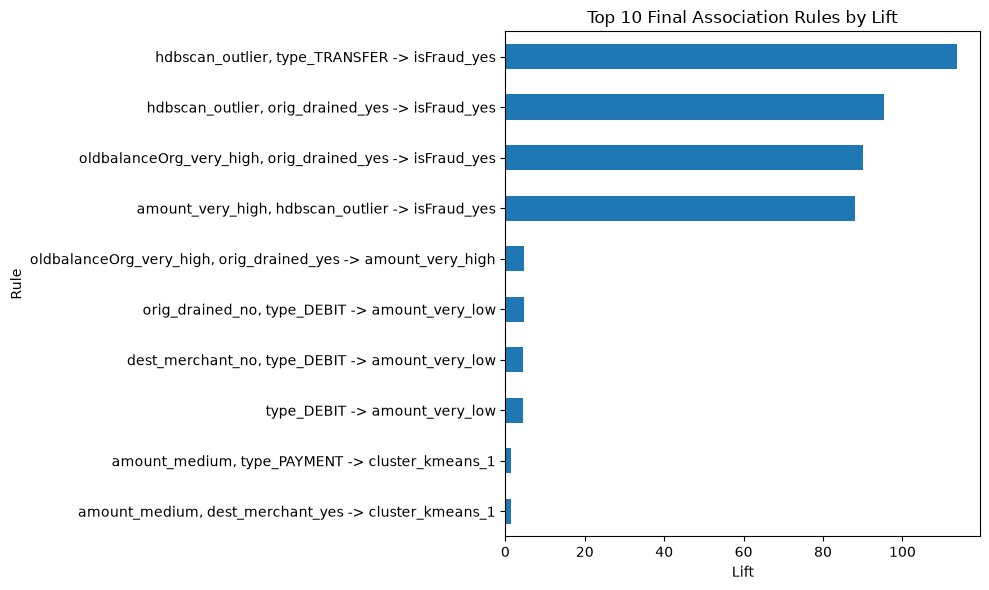

In [14]:
if len(top_10_final) > 0:
    plot_df = top_10_final.copy()
    plot_df["rule"] = plot_df["antecedents_str"] + " -> " + plot_df["consequents_str"]

    plt.figure(figsize=(10, 6))
    plot_df.set_index("rule")["lift"].sort_values().plot(kind="barh")
    plt.title("Top 10 Final Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")
    plt.tight_layout()
    plt.show()
else:
    print("No top rules available to plot.")

In [15]:
top_10_final = top_10_final[
    ~top_10_final["antecedents_str"].str.contains(
        "isFraud_no|hdbscan_normal|orig_drained_no",
        regex=True,
        na=False
    )
].copy()

if len(top_10_final) < 10:
    existing_pairs = set(
        zip(top_10_final["antecedents_str"], top_10_final["consequents_str"])
    )

    filler = report_rules[
        ~report_rules["antecedents_str"].str.contains(
            "isFraud_no|hdbscan_normal|orig_drained_no",
            regex=True,
            na=False
        )
    ].copy()

    filler = filler[
        ~filler.apply(
            lambda row: (row["antecedents_str"], row["consequents_str"]) in existing_pairs,
            axis=1
        )
    ]

    top_10_final = pd.concat(
        [top_10_final, filler.head(10 - len(top_10_final))],
        ignore_index=True
    )

top_10_final = top_10_final.head(10).copy()

display(top_10_final[[
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]])

,antecedents_str,consequents_str,support,confidence,lift,leverage,conviction
0,"hdbscan_outlier, type_TRANSFER",isFraud_yes,0.000119,0.146664,113.842310,0.000117,1.170362
1,"hdbscan_outlier, orig_drained_yes",isFraud_yes,0.000231,0.122942,95.428902,0.000229,1.138706
2,"oldbalanceOrg_very_high, orig_drained_yes",isFraud_yes,0.000834,0.116115,90.129927,0.000825,1.129912
3,"amount_very_high, hdbscan_outlier",isFraud_yes,0.000153,0.113382,88.008077,0.000151,1.126428
4,"amount_medium, type_PAYMENT",cluster_kmeans_1,0.010306,0.547158,1.444935,0.003173,1.372061
5,"amount_medium, dest_merchant_yes",cluster_kmeans_1,0.010306,0.547158,1.444935,0.003173,1.372061
6,"oldbalanceOrg_very_high, orig_drained_yes",amount_very_high,0.006731,0.937150,4.685749,0.005294,12.728690
7,"dest_merchant_no, type_DEBIT",amount_very_low,0.005905,0.906763,4.533810,0.004602,8.580272
8,type_DEBIT,amount_very_low,0.005905,0.906763,4.533810,0.004602,8.580272
9,"oldbalanceOrg_low, type_TRANSFER",orig_drained_yes,0.014506,0.984049,4.117581,0.010983,47.710313


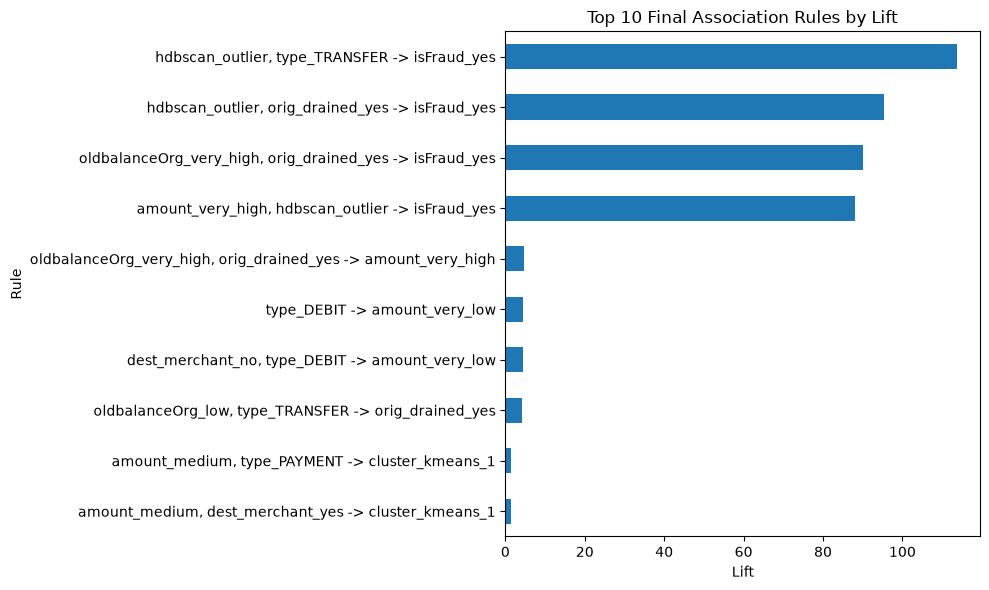

In [16]:
if len(top_10_final) > 0:
    plot_df = top_10_final.copy()
    plot_df["rule"] = plot_df["antecedents_str"] + " -> " + plot_df["consequents_str"]

    plt.figure(figsize=(10, 6))
    plot_df.set_index("rule")["lift"].sort_values().plot(kind="barh")
    plt.title("Top 10 Final Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")
    plt.tight_layout()
    plt.show()
else:
    print("No top rules available to plot.")